# Assignment 5 - Perceptron
Author: Bryce Emery

### Importing libraries and dataset:

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
#import random as rand
seed = 260421
#rand.seed(seed)

np.random.seed(seed)

In [86]:
file = open('data.csv')
df = pd.read_csv(file, names=['x1', 'x2', 'label'])
print("Shape: ",df.shape)
print("Cols", df.columns)
print(df.info())

Shape:  (100, 3)
Cols Index(['x1', 'x2', 'label'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      100 non-null    float64
 1   x2      100 non-null    float64
 2   label   100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB
None


## Part 1: Heuristic Perceptron

### Visualize the data with a plot

In [87]:
# Define Features and Targets

X = df.iloc[:, [0,1]].values
y = df.iloc[:, 2].values


<Axes: xlabel='x1', ylabel='x2'>

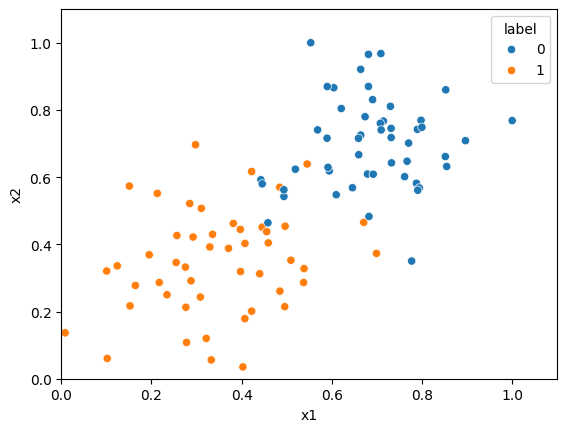

In [88]:
# Setting boundaries.
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)

sns.scatterplot(
    x=df.iloc[:,0], y=df.iloc[:, 1], hue=df.iloc[:, 2]
)


### Implement a perceptron using the heuristic approach:

In [89]:
## Function definitions

def activation(W, x, b, fn='step'):
    linear_result = np.dot(x, W) + b
    if (fn  == 'step'):
        if (linear_result >= 0):
            return 1
        else:
            return 0
    if (fn == "sigmoid"):
        if ( 1 / (1 + np.exp(-linear_result)) >= 0.5 ):
            return 1
        else:
            return 0

# I generated this function using ChatGPT
def plot_boundary(weights, bias, color='black', linestyle='solid', label=None):
    x_vals = np.linspace(plt.xlim()[0], plt.xlim()[1], 100)
    
    # w1*x1 + w2*x2 + b = 0 → solve for x2
    y_vals = -(weights[0]*x_vals + bias) / weights[1]
    
    plt.plot(x_vals, y_vals, color=color, linestyle=linestyle, label=label)

def perceptron(X, y, lr=0.5, epochs=1):
    num_samples, num_variables = X.shape
    scaling = 1 / X.std()
    
    W = np.random.randn(num_variables) * scaling
    b = np.random.randn() * scaling

    # Used for visualizing later
    records = [(W.copy(), b)]
    for epoch in range(epochs):
        for i in range(num_samples):
            prediction = activation(W, X[i], b)
            if prediction != y[i]:
                error = y[i] - prediction # y - yhat
                W += (lr * error * X[i]) 
                b += (lr * error)
        if epoch % 10 + 1 == 1: # Every 10 epochs, starting at 1
            records.append((W.copy(), b))
    # Tuple record of all weights, final Weights, final bias.
    return records, W, b 


### Simple Hueristic Model

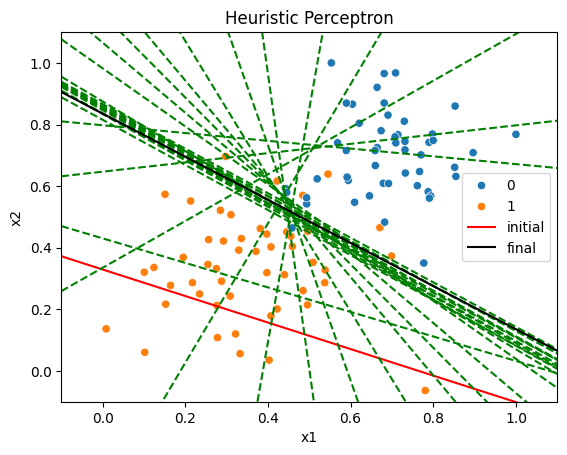

In [90]:
## Training

records, weights, bias = perceptron(X, y, lr=0.01, epochs=250)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Heuristic Perceptron")
plt.show()



### Using different hyperparameters

## Part 2: Gradient Descent

In [91]:
def gradient_descent(X, y, lr=0.05, epochs=100):
    num_samples, num_variables = X.shape
    sigma = X.std()
    mu = X.mean()
#    epoch_count_ten = True if epochs > 20 else False # Simple scaling for recording
    
    W = np.random.randn(num_variables) * sigma + mu # Ensure sample exists inside the 
    b = np.random.randn() * sigma + mu

    # Used for visualizing later
    records = [(W.copy(), b)]
    error_rec = []
    
    for epoch in range(epochs):
        error = 1
        log_losses = []
        for i in range(num_samples):
            prediction = activation(W, X[i], b, fn='sigmoid')
            error = y[i] - prediction # y - yhat
            ### I think the issue here is the rate of change between the Weights and the bias... ###
            ### I was thinking it's too small, but maybe it's too big??
            W += (lr * error * X[i]) 
            b += (lr * error)
            pred = np.clip(prediction, 1e-15, 1 - 1e-15)
            log_loss = -(y[i] * np.log(pred) + (1-y[i]) * np.log(1 - pred))
            log_losses.append(log_loss)
            
        if epoch % 10 + 1 == 1: # Every 10 epochs, starting at 1
            records.append((W.copy(), b))
            error_rec.append(np.mean(log_losses))
#        if (epoch_count_ten and epoch % 10 + 1 == 1): # Every 10 epochs, starting at 1
#            records.append((W.copy(), b))
#        else:
#            records.append((W.copy(), b))
    
    # Tuple record of all weights, final Weights, final bias.
    return records, W, b, error_rec



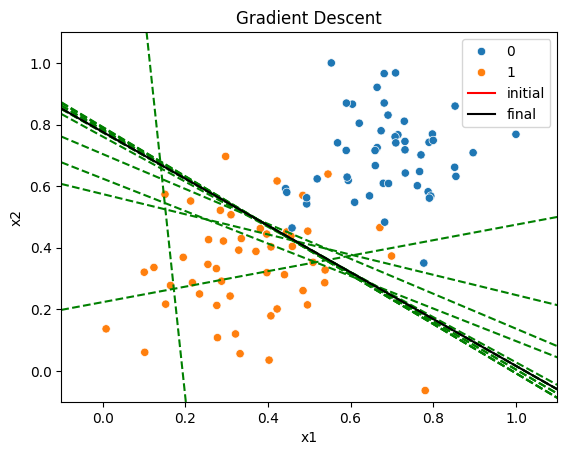

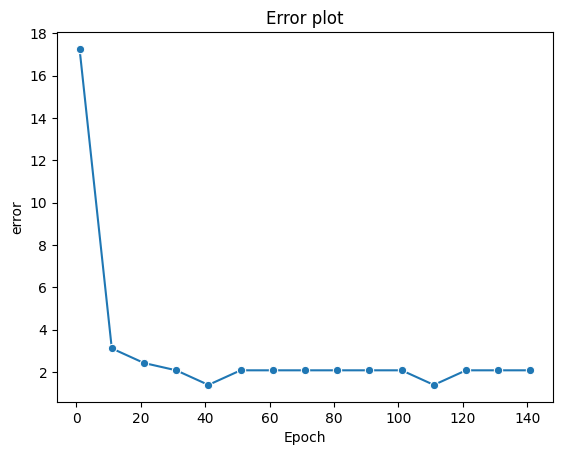

In [92]:
## Training
num_epochs = 150
records, weights, bias, loss = gradient_descent(X, y, lr=0.005, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

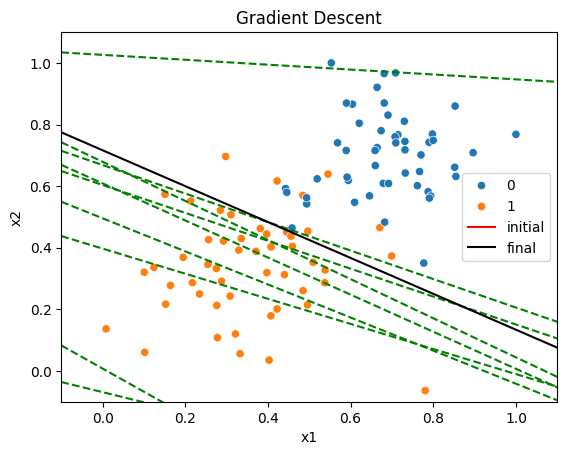

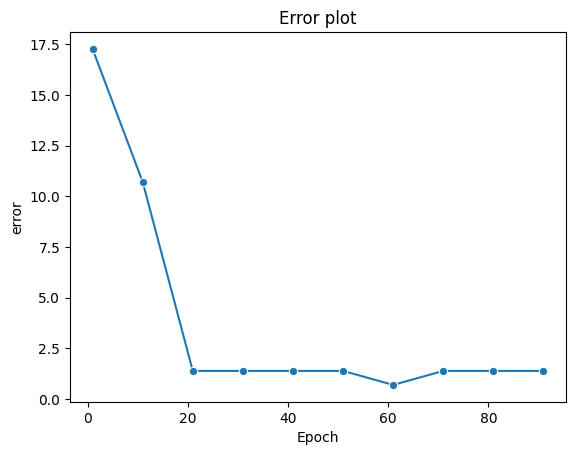

In [93]:
## Training
num_epochs = 100
records, weights, bias, loss = gradient_descent(X, y, lr=0.005, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

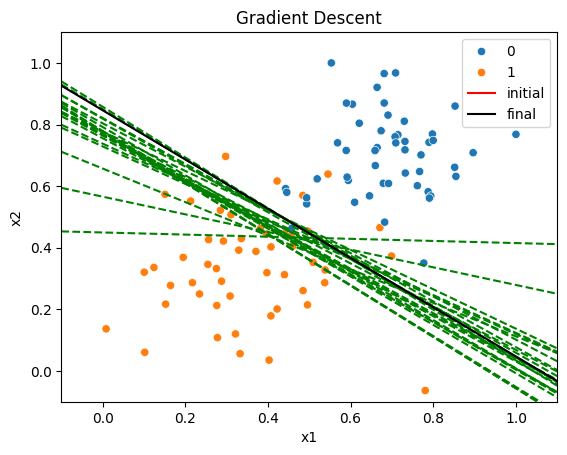

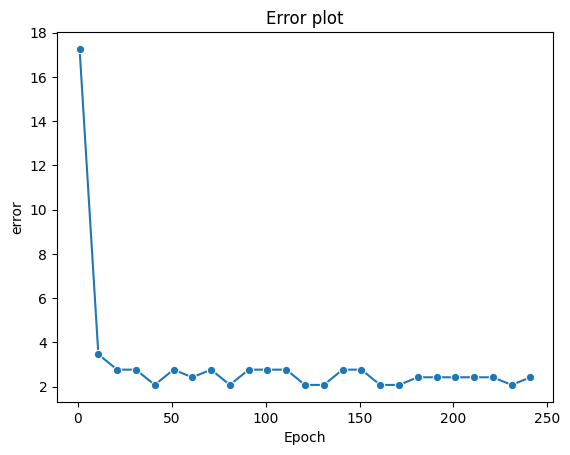

In [94]:
## Training
num_epochs = 250
records, weights, bias, loss = gradient_descent(X, y, lr=0.005, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

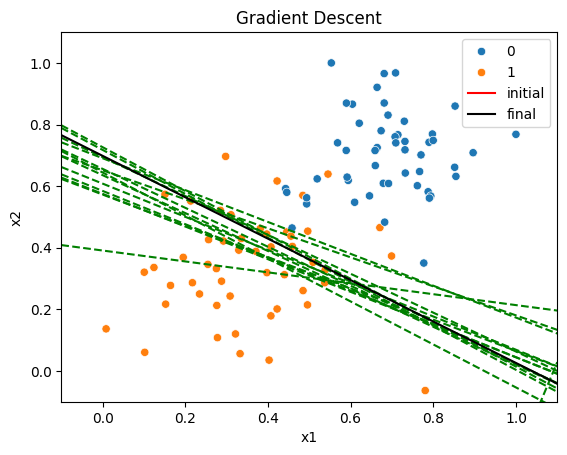

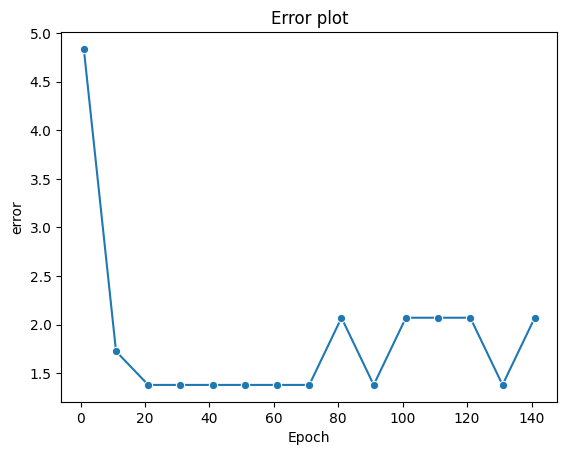

In [95]:
## Training
num_epochs = 150
records, weights, bias, loss = gradient_descent(X, y, lr=0.05, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

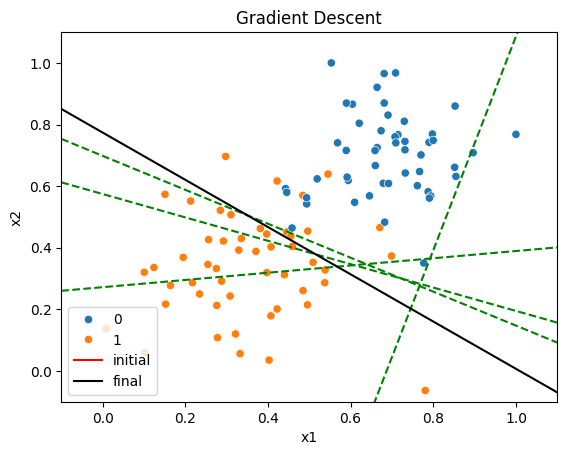

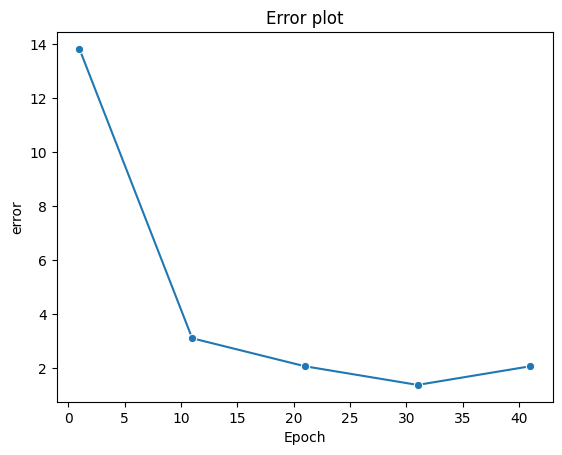

In [96]:
## Training
num_epochs = 50
learning_rate = 0.01
records, weights, bias, loss = gradient_descent(X, y, lr=learning_rate, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

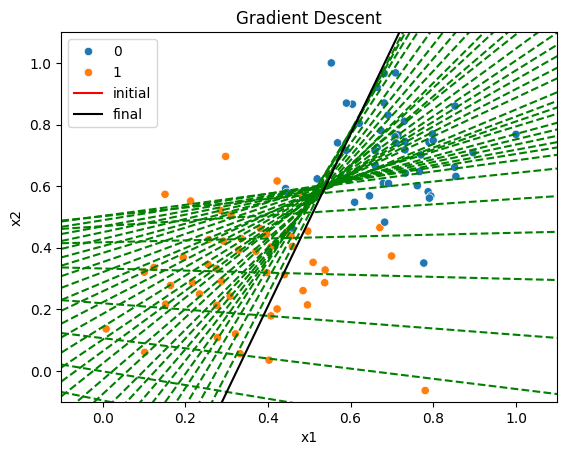

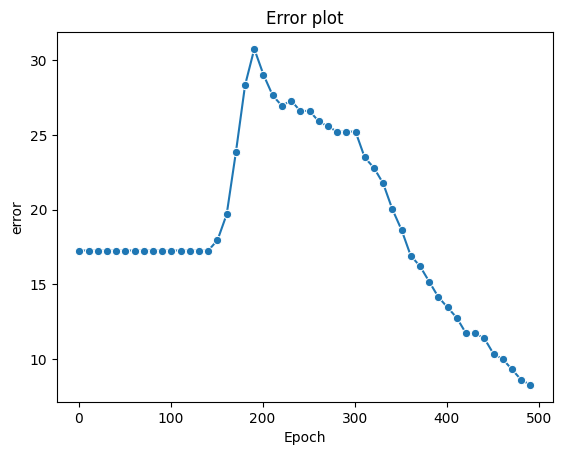

In [97]:
## Training
num_epochs = 500
learning_rate = 0.0001
records, weights, bias, loss = gradient_descent(X, y, lr=learning_rate, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

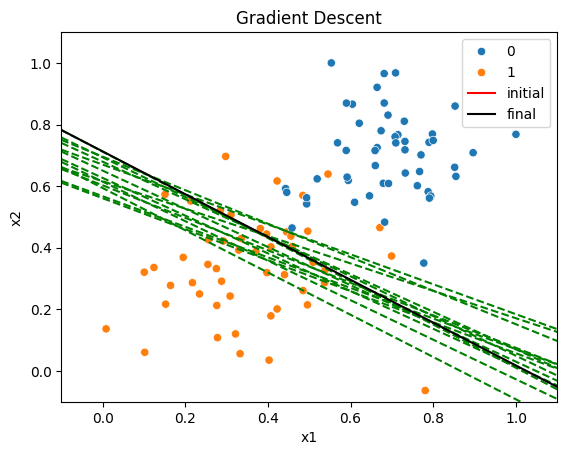

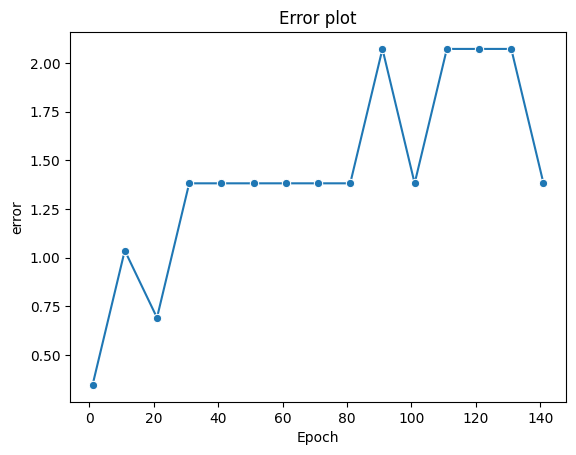

In [98]:
## Training
num_epochs = 150
learning_rate = 0.5
records, weights, bias, loss = gradient_descent(X, y, lr=learning_rate, epochs=num_epochs)

## Rendering

sns.scatterplot(x=df['x1'], y=df['x2'], hue=df['label'])

# Setting boundaries.
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# initial line (red)
plot_boundary(records[0][0], records[0][1] , color='red', label='initial')

# intermediate (green dashed)
for w, b in records[1:-1]:
    plot_boundary(w, b, color='green', linestyle='dashed')

# final (black)
plot_boundary(records[-1][0], records[-1][1], color='black', label='final')

plt.legend()
plt.title("Gradient Descent")
plt.show()

loss_df = pd.DataFrame({
    "Number of Epochs": list(range(1, num_epochs, 10)),
    "Log Loss": loss
    })

sns.lineplot(data=loss_df, x="Number of Epochs", y="Log Loss", marker="o")

plt.xlabel("Epoch")
plt.ylabel("error")
plt.title("Error plot")
plt.show()

### Analysis

The gradient descent model showed much greater ability to converge quickly on a good split over the single perceptron hueristic model. Requiring far fewer epochs to do so. We can see this speed in the resultant error plots. The error starts out quite high (do to the random starting conditions), and quickly plateaus at a low, somewhat consistant value across the epochs.
Notable, it seems that running for too many epochs results in works outcomes.

This can be very easily seen in the difference between the 150 and 250 epoch count tests. Where the 150 is visibly orbiting an error value of 2, where the 250 epochs hovers closer to 3.
That the error did not stablize below one suggests some issues with the model as is.

Other observations are that the learning rate being very high results in an odd climbing pattern that suggests (an expected) instability.
A deeply slow learning rate with many epochs results in the same fast plateauing effect, it just begins at a much later epoch than a more appropriate learning rate. 